# Setup check

Run this notebook first. It loads the tools the course uses and draws one small chart. If every cell runs without an error, your environment is ready.

To run a cell, select it and press Shift+Enter. The output appears just below it.

## Before you run this

You should have arrived here by starting the course folder's launcher:

- **Windows**: double-click `start-jupyter.bat`
- **macOS and Linux**: in a terminal, `cd` to the course folder and run `sh start-jupyter.sh`

That builds the course environment the first time and starts JupyterLab every time, so if it worked, everything below should just run. Leave the window it is running in alone while you work.

If you got here some other way and the next cell reports a missing library, Jupyter is running outside the course environment. Close it and start again with the launcher. The README walks through the Mac steps one at a time.

The next cell loads every library the course uses. The first time you run it, expect a wait of up to half a minute while Python caches the libraries as it loads them. Every run after that takes about a second.

In [1]:
import re
from pathlib import Path

import sotu
import pandas
import numpy
import matplotlib.pyplot as plt
import seaborn
import plotly.express
import sklearn.feature_extraction.text
import scipy.cluster.hierarchy
import nltk
import wordcloud
import networkx
import liwc
import corpus_tools

print('All tools loaded.')

All tools loaded.


The State of the Union corpus ships inside the `sotu` package rather than as a separate download, so a clean load here also tells you the data is in place.

In [2]:
df = sotu.load()
print(len(df), 'speeches loaded.')

237 speeches loaded.


The German stopword list is the one thing this course fetches over the network. Downloading it now means a blocked connection shows up here, where there is time to fix it, rather than midway through day 3.

A failed download prints its complaint rather than raising an error, so it is the line after it that stops the cell. Reaching the count below is what proves the list arrived.

In [3]:
nltk.download('stopwords')
german_stopwords = nltk.corpus.stopwords.words('german')
print(len(german_stopwords), 'German stopwords ready.')

232 German stopwords ready.


[nltk_data] Downloading package stopwords to /home/brian/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


The libraries are only half the setup. The dictionaries and the Nietzsche texts travel in the same zip as the notebooks, so this checks they arrived and sit where the lessons look for them.

In [4]:
expected_dictionaries = [
    'dictionaries/macdvirtue.dic',
    'dictionaries/nietzsche.dic',
    'dictionaries/nuke.dic',
]
missing = []
for path in expected_dictionaries:
    if not Path(path).exists():
        missing.append(path)

nietzsche_texts = sorted(Path('nietzsche').glob('*.txt'))
if len(nietzsche_texts) != 15:
    missing.append(f'nietzsche/ has {len(nietzsche_texts)} texts, expected 15')

if missing:
    print('MISSING, so some lessons will not run:')
    for item in missing:
        print('   ', item)
else:
    print(len(expected_dictionaries), 'dictionaries and', len(nietzsche_texts), 'Nietzsche texts found.')

3 dictionaries and 15 Nietzsche texts found.


One small chart to finish: how many speeches each party gave. A chart appearing below means plotting works in your browser, which is the last thing that has to be true before the lessons will run.

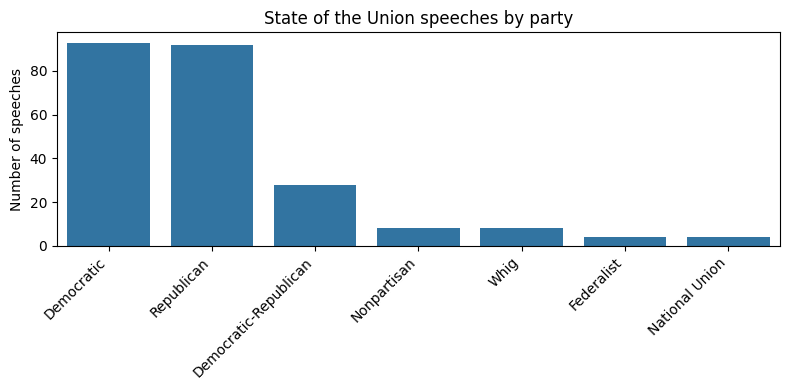

In [5]:
party_counts = df['party'].value_counts()
plt.figure(figsize=(8, 4))
axes = seaborn.countplot(data=df, x='party', order=party_counts.index)
axes.set(xlabel='', ylabel='Number of speeches',
         title='State of the Union speeches by party')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## You're set

If every cell above ran, your environment is ready. Open `1a-sotu-corpus.ipynb` to start the first lesson.

If a cell showed an error, read the last line of the message. It names what is missing. The usual cause is Jupyter running outside the course environment, so close it and start again with the launcher, or ask an instructor.